# Qwen3.5-VL T4 Smoke Test: Synthetic Output Inspection

Notebook này chỉ để xem output thô của base VLM trước khi fine-tune.

- Không cần EduVidQA dataset.
- Không cần Google Drive tarball.
- Không gọi Gemini.
- Không train.
- Tự tạo vài ảnh slide giả bằng PIL, kèm transcript/question giả.
- Generate `raw_output`, `cleaned_output`, và flag nhiễu như `<think>`, role marker, prompt echo, repetition, output quá ngắn/quá dài.

Dùng notebook này trước để quyết định post-process cần đưa vào pipeline chính.

In [1]:
# 0) Smoke-test config
BASE_MODEL = "Qwen/Qwen3.5-4B"
MAX_SEQ_LENGTH = 4096
LOAD_IN_4BIT = True
GPU_MEMORY_UTILIZATION = 0.80

MAX_NEW_TOKENS = 384
TEMPERATURE = 0.1
TOP_P = 0.9
REPETITION_PENALTY = 1.05
NO_REPEAT_NGRAM_SIZE = 0  # Set 4 if outputs repeat phrases badly.

OUTPUT_DIR = "/content/qwen35_vl_t4_smoke_outputs"
SEED = 42

print("Smoke config:", {
    "base_model": BASE_MODEL,
    "max_new_tokens": MAX_NEW_TOKENS,
    "temperature": TEMPERATURE,
    "top_p": TOP_P,
    "repetition_penalty": REPETITION_PENALTY,
})

Smoke config: {'base_model': 'Qwen/Qwen3.5-4B', 'max_new_tokens': 384, 'temperature': 0.1, 'top_p': 0.9, 'repetition_penalty': 1.05}


In [2]:
# 1) Install dependencies + repair Pillow if Colab has a mixed install
import importlib
import os
import subprocess
import sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "unsloth[colab-new]", "accelerate", "bitsandbytes", "pandas",
])

# Colab sometimes ends up with mixed Pillow files after upgrades, causing:
# ImportError: cannot import name '_Ink' from 'PIL._typing'.
# Force reinstall Pillow in a clean no-cache pass before importing PIL.
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "--force-reinstall", "--no-cache-dir",
    "Pillow==11.3.0",
])

importlib.invalidate_caches()
try:
    from PIL import Image, ImageDraw, ImageFont
    print("Pillow import OK:", Image.__version__)
except ImportError as exc:
    print("Pillow is still cached in a broken state:", exc)
    print("Runtime > Restart runtime, then rerun from cell 0. The reinstall above is already done.")
    raise

Pillow import OK: 11.3.0


In [3]:
# 2) Imports + GPU check
import json
import random
import re
import subprocess
import textwrap
import time
from collections import Counter
from pathlib import Path

import pandas as pd
import torch
from PIL import Image, ImageDraw, ImageFont
from IPython.display import Markdown, display

print("Pillow version:", Image.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    subprocess.run(["nvidia-smi"], check=False)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

Pillow version: 11.3.0
CUDA available: True


Synthetic cases: 4


,id,title,question,image_path
0,synthetic_axis_npmax,NumPy reductions,"Trong np.max, axis nghĩa là gì? Nó có phải sha...",/content/qwen35_vl_t4_smoke_outputs/synthetic_...
1,synthetic_softmax_formula,Softmax classifier,Why does cross entropy get large when the corr...,/content/qwen35_vl_t4_smoke_outputs/synthetic_...
2,synthetic_gradient_flow,Backpropagation,What does upstream gradient mean in backpropag...,/content/qwen35_vl_t4_smoke_outputs/synthetic_...
3,synthetic_visual_graph,Validation curve,What visual sign in this slide suggests overfi...,/content/qwen35_vl_t4_smoke_outputs/synthetic_...


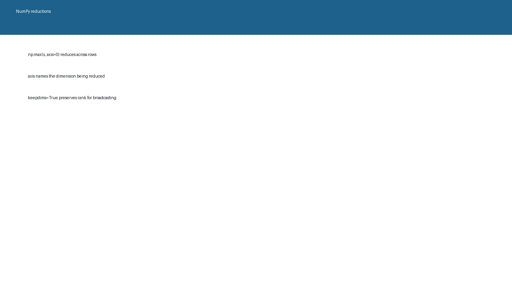

In [4]:
# 3) Generate synthetic slide images + fake transcript/question cases

def _font(size=28):
    try:
        return ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", size)
    except Exception:
        return ImageFont.load_default()


def make_slide(path, title, lines, accent=(31, 97, 141)):
    img = Image.new("RGB", (1280, 720), "white")
    draw = ImageDraw.Draw(img)
    draw.rectangle([0, 0, 1280, 86], fill=accent)
    draw.text((40, 22), title, fill="white", font=_font(34))
    y = 130
    for line in lines:
        wrapped = textwrap.wrap(line, width=58)
        for part in wrapped:
            draw.text((70, y), part, fill=(20, 25, 30), font=_font(30))
            y += 44
        y += 10
    img.save(path, quality=95)
    return path

cases = [
    {
        "id": "synthetic_axis_npmax",
        "title": "NumPy reductions",
        "slide_lines": [
            "np.max(x, axis=0) reduces across rows",
            "axis names the dimension being reduced",
            "keepdims=True preserves rank for broadcasting",
        ],
        "transcript": "[00:12] Axis tells NumPy which dimension to reduce over. [00:31] It is not the final output shape; it is the dimension removed unless keepdims is enabled.",
        "question": "Trong np.max, axis nghĩa là gì? Nó có phải shape output không?",
    },
    {
        "id": "synthetic_softmax_formula",
        "title": "Softmax classifier",
        "slide_lines": [
            "scores = W x + b",
            "p_i = exp(s_i) / sum_j exp(s_j)",
            "Cross entropy penalizes low probability on the true class",
        ],
        "transcript": "[03:44] We convert raw scores into probabilities with softmax. [04:05] Cross entropy becomes large when the true class probability is small.",
        "question": "Why does cross entropy get large when the correct class has low softmax probability?",
    },
    {
        "id": "synthetic_gradient_flow",
        "title": "Backpropagation",
        "slide_lines": [
            "local gradient x upstream gradient",
            "chain rule composes derivatives",
            "cache forward values needed by backward pass",
        ],
        "transcript": "[10:18] Backprop multiplies a local gradient by the upstream gradient. [10:42] Cached forward values often make the derivative easy to compute.",
        "question": "What does upstream gradient mean in backpropagation?",
    },
    {
        "id": "synthetic_visual_graph",
        "title": "Validation curve",
        "slide_lines": [
            "training loss keeps decreasing",
            "validation loss starts increasing after epoch 8",
            "gap indicates overfitting",
        ],
        "transcript": "[22:10] Here the train curve keeps going down, but validation loss rises. [22:25] That divergence is a common overfitting signal.",
        "question": "What visual sign in this slide suggests overfitting?",
    },
]

for idx, case in enumerate(cases, start=1):
    image_path = Path(OUTPUT_DIR) / f"{case['id']}.jpg"
    make_slide(image_path, case["title"], case["slide_lines"], accent=[(31,97,141), (100,68,135), (34,121,84), (151,85,30)][idx-1])
    case["image_path"] = str(image_path)
    case["text_input"] = f"Transcript window around the frame timestamp:\n{case['transcript']}\n\nStudent question:\n{case['question']}"

print("Synthetic cases:", len(cases))
display(pd.DataFrame([{k: c[k] for k in ["id", "title", "question", "image_path"]} for c in cases]))
Image.open(cases[0]["image_path"]).resize((512, 288))

In [5]:
# 4) Prompt setup
SYSTEM_PROMPT = """You are an expert computer science educator answering questions about a lecture video.
Use only the provided frame and transcript window. If the context is insufficient, say so clearly.
Answer as a helpful tutor in one concise paragraph. Do not reveal hidden reasoning or <think> text."""

USER_TEMPLATE = """{system_prompt}

{record_text_input}

Answer the student question using the frame and transcript. Return only the final answer."""


def make_instruction(case):
    return USER_TEMPLATE.format(system_prompt=SYSTEM_PROMPT, record_text_input=case["text_input"])

print(make_instruction(cases[0]))

You are an expert computer science educator answering questions about a lecture video.
Use only the provided frame and transcript window. If the context is insufficient, say so clearly.
Answer as a helpful tutor in one concise paragraph. Do not reveal hidden reasoning or <think> text.

Transcript window around the frame timestamp:
[00:12] Axis tells NumPy which dimension to reduce over. [00:31] It is not the final output shape; it is the dimension removed unless keepdims is enabled.

Student question:
Trong np.max, axis nghĩa là gì? Nó có phải shape output không?

Answer the student question using the frame and transcript. Return only the final answer.


In [6]:
# 5) Load base VLM on T4
from unsloth import FastVisionModel

print("BASE_MODEL:", BASE_MODEL)
model, processor = FastVisionModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=LOAD_IN_4BIT,
    fast_inference=False,
    gpu_memory_utilization=GPU_MEMORY_UTILIZATION,
)

print("BASE_MODEL loaded:", BASE_MODEL)
print("Processor:", type(processor))
print("Tokenizer:", type(processor.tokenizer))

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
BASE_MODEL: Qwen/Qwen3.5-4B
==((====))==  Unsloth 2026.5.2: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


HTTP Error 500 thrown while requesting GET https://huggingface.co/api/models/unslothai/1/xet-read-token/7ec782b7604cd9ea0781c23a4270f031650f5617
Retrying in 1s [Retry 1/5].


Unsloth: Using float16 precision for qwen3_5 won't work! Using float32.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

BASE_MODEL loaded: Qwen/Qwen3.5-4B
Processor: <class 'transformers.models.qwen3_vl.processing_qwen3_vl.Qwen3VLProcessor'>
Tokenizer: <class 'transformers.tokenization_utils_tokenizers.TokenizersBackend'>


In [7]:
# 6) Cleaning and noise flagging helpers
THINK_BLOCK_RE = re.compile(r"<think\b[^>]*>.*?</think>", re.I | re.S)
UNFINISHED_THINK_RE = re.compile(r"<think\b[^>]*>.*$", re.I | re.S)
ROLE_MARKER_RE = re.compile(r"(^|\n)\s*(assistant|user|system|model)\s*:", re.I)
PROMPT_ECHO_MARKERS = [
    "Transcript window", "Student question", "Answer the student question",
    "Return only the final answer", "You are an expert computer science educator",
]
SYSTEM_LEAK_MARKERS = ["system prompt", "hidden reasoning", "do not reveal", "provided frame and transcript"]
STOP_MARKERS = ["\nUser:", "\nSystem:", "\nStudent question:", "\nTranscript window"]


def strip_thinking(text):
    text = THINK_BLOCK_RE.sub("", text or "")
    text = UNFINISHED_THINK_RE.sub("", text)
    return text.strip()


def strip_role_prefixes(text):
    return re.sub(r"^\s*(assistant|model)\s*:\s*", "", text or "", flags=re.I).strip()


def truncate_at_prompt_echo(text):
    out = text or ""
    for marker in STOP_MARKERS:
        pos = out.find(marker)
        if pos > 0:
            out = out[:pos]
    return out.strip()


def normalize_answer(text):
    text = strip_thinking(text)
    text = truncate_at_prompt_echo(text)
    text = strip_role_prefixes(text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def repeated_ngram_flag(text, n=4, threshold=3):
    words = re.findall(r"\w+", (text or "").lower())
    if len(words) < n * threshold:
        return False
    grams = Counter(tuple(words[i:i+n]) for i in range(len(words) - n + 1))
    return bool(grams and max(grams.values()) >= threshold)


def repeated_line_flag(text):
    lines = [ln.strip().lower() for ln in (text or "").splitlines() if ln.strip()]
    if len(lines) < 3:
        return False
    counts = Counter(lines)
    return max(counts.values()) >= 3


def word_count(text):
    return len((text or "").split())


def inspect_output(raw_output):
    raw = raw_output or ""
    cleaned = normalize_answer(raw)
    flags = []
    if re.search(r"<think\b", raw, flags=re.I):
        flags.append("think_tag")
    if re.search(r"<think\b", raw, flags=re.I) and not re.search(r"</think>", raw, flags=re.I):
        flags.append("unclosed_think")
    if ROLE_MARKER_RE.search(raw):
        flags.append("role_marker")
    if any(marker.lower() in raw.lower() for marker in PROMPT_ECHO_MARKERS):
        flags.append("prompt_echo")
    if any(marker.lower() in raw.lower() for marker in SYSTEM_LEAK_MARKERS):
        flags.append("system_leak")
    if repeated_line_flag(raw) or repeated_ngram_flag(raw):
        flags.append("repetition")
    wc = word_count(cleaned)
    if wc < 8:
        flags.append("empty_or_too_short")
    if wc > 220:
        flags.append("too_long")
    if not cleaned:
        flags.append("cleaned_empty")
    return cleaned, flags


def recommended_action(flags):
    actions = []
    if "think_tag" in flags or "unclosed_think" in flags:
        actions.append("strip <think> blocks and keep enable_thinking=False")
    if "role_marker" in flags:
        actions.append("strip leading Assistant/User/System role prefixes")
    if "prompt_echo" in flags or "system_leak" in flags:
        actions.append("truncate prompt echo markers and tighten prompt")
    if "repetition" in flags:
        actions.append("try repetition_penalty/no_repeat_ngram_size or lower max_new_tokens")
    if "empty_or_too_short" in flags or "cleaned_empty" in flags:
        actions.append("inspect processor/model load and consider less restrictive prompt")
    if "too_long" in flags:
        actions.append("lower max_new_tokens or enforce one-paragraph answer")
    return "; ".join(actions) if actions else "none"

print("helpers ready")

helpers ready


In [8]:
# 7) Generation helper

def processor_inputs(image, text_prompt):
    try:
        return processor(
            images=image,
            text=text_prompt,
            add_special_tokens=False,
            return_tensors="pt",
        ).to("cuda")
    except TypeError:
        try:
            return processor(
                text=[text_prompt],
                images=[image],
                videos=[],
                padding=True,
                return_tensors="pt",
            ).to("cuda")
        except TypeError:
            return processor(
                image,
                text_prompt,
                add_special_tokens=False,
                return_tensors="pt",
            ).to("cuda")


def generate_one(case, max_new_tokens=MAX_NEW_TOKENS):
    FastVisionModel.for_inference(model)
    image = Image.open(case["image_path"]).convert("RGB")
    messages = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": make_instruction(case)}]}]
    try:
        text_prompt = processor.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
    except TypeError:
        text_prompt = processor.tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    inputs = processor_inputs(image, text_prompt)
    input_len = inputs["input_ids"].shape[-1]
    kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=TEMPERATURE > 0,
        temperature=TEMPERATURE,
        top_p=TOP_P,
        repetition_penalty=REPETITION_PENALTY,
        use_cache=True,
    )
    if NO_REPEAT_NGRAM_SIZE:
        kwargs["no_repeat_ngram_size"] = NO_REPEAT_NGRAM_SIZE
    t0 = time.perf_counter()
    with torch.inference_mode():
        output_ids = model.generate(**inputs, **kwargs)
    latency = time.perf_counter() - t0
    raw = processor.tokenizer.decode(output_ids[0][input_len:], skip_special_tokens=True)
    cleaned, flags = inspect_output(raw)
    return {
        "id": case["id"],
        "title": case["title"],
        "question": case["question"],
        "raw_output": raw,
        "cleaned_output": cleaned,
        "flags": flags,
        "recommended_action": recommended_action(flags),
        "raw_word_count": word_count(raw),
        "cleaned_word_count": word_count(cleaned),
        "latency_sec": round(latency, 3),
        "output_tokens": int(output_ids.shape[-1] - input_len),
    }

sanity = generate_one(cases[0], max_new_tokens=128)
print(json.dumps({k: sanity[k] for k in ["id", "flags", "recommended_action", "cleaned_output"]}, ensure_ascii=False, indent=2))

{
  "id": "synthetic_axis_npmax",
  "flags": [],
  "recommended_action": "none",
  "cleaned_output": "Trong `np.max`, tham số `axis` chỉ định chiều (dimension) mà hàm sẽ thực hiện phép lấy giá trị lớn nhất — ví dụ, nếu `axis=0`, nó sẽ giảm theo hàng (rows), còn `axis=1` thì giảm theo cột (columns). Không, `axis` không phải là shape đầu ra; nó chỉ nói rõ chiều nào bị loại bỏ trong quá trình giảm (reduce). Nếu bạn muốn giữ lại kích thước của chiều đó trong kết quả, hãy sử dụng `keepdims=True`."
}


In [9]:
# 8) Run synthetic smoke batch and save outputs
results = []
for i, case in enumerate(cases, start=1):
    print(f"[{i}/{len(cases)}] {case['id']}")
    result = generate_one(case)
    results.append({
        **result,
        "text_input": case["text_input"],
        "image_path": case["image_path"],
    })

jsonl_path = Path(OUTPUT_DIR) / "synthetic_t4_smoke_outputs.jsonl"
json_path = Path(OUTPUT_DIR) / "synthetic_t4_smoke_outputs.json"
with jsonl_path.open("w", encoding="utf-8") as f:
    for item in results:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")
json_path.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved", jsonl_path)
print("saved", json_path)

[1/4] synthetic_axis_npmax
[2/4] synthetic_softmax_formula
[3/4] synthetic_gradient_flow
[4/4] synthetic_visual_graph
saved /content/qwen35_vl_t4_smoke_outputs/synthetic_t4_smoke_outputs.jsonl
saved /content/qwen35_vl_t4_smoke_outputs/synthetic_t4_smoke_outputs.json


In [10]:
# 9) Summary table: decide what post-processing is needed
summary_rows = []
for r in results:
    summary_rows.append({
        "id": r["id"],
        "flags": ", ".join(r["flags"]),
        "recommended_action": r["recommended_action"],
        "raw_words": r["raw_word_count"],
        "cleaned_words": r["cleaned_word_count"],
        "latency_sec": r["latency_sec"],
        "tokens": r["output_tokens"],
        "cleaned_preview": r["cleaned_output"][:260],
    })

df = pd.DataFrame(summary_rows)
display(df)

flag_counts = Counter(flag for r in results for flag in r["flags"])
print("Flag counts:", dict(flag_counts))
print("Samples with any flag:", sum(1 for r in results if r["flags"]), "/", len(results))

recommended_filters = []
if flag_counts.get("think_tag") or flag_counts.get("unclosed_think"):
    recommended_filters.append("strip_thinking")
if flag_counts.get("role_marker"):
    recommended_filters.append("strip_role_prefixes")
if flag_counts.get("prompt_echo") or flag_counts.get("system_leak"):
    recommended_filters.append("truncate_prompt_echo")
if flag_counts.get("repetition"):
    recommended_filters.append("generation_repetition_guard")
print("Recommended filters:", recommended_filters or ["none"])

summary_path = Path(OUTPUT_DIR) / "synthetic_t4_smoke_summary.json"
summary_path.write_text(
    json.dumps({
        "flag_counts": dict(flag_counts),
        "recommended_filters": recommended_filters,
        "config": {
            "base_model": BASE_MODEL,
            "max_new_tokens": MAX_NEW_TOKENS,
            "temperature": TEMPERATURE,
            "top_p": TOP_P,
            "repetition_penalty": REPETITION_PENALTY,
            "no_repeat_ngram_size": NO_REPEAT_NGRAM_SIZE,
        },
    }, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
print("saved", summary_path)

,id,flags,recommended_action,raw_words,cleaned_words,latency_sec,tokens,cleaned_preview
0,synthetic_axis_npmax,,none,75,75,15.378,109,"Trong `np.max`, tham số `axis` chỉ định chiều ..."
1,synthetic_softmax_formula,,none,75,75,16.497,87,Cross entropy measures how well the model's pr...
2,synthetic_gradient_flow,,none,107,107,26.827,149,"In backpropagation, the **upstream gradient** ..."
3,synthetic_visual_graph,,none,49,49,9.805,60,The visual sign suggesting overfitting in this...


Flag counts: {}
Samples with any flag: 0 / 4
Recommended filters: ['none']
saved /content/qwen35_vl_t4_smoke_outputs/synthetic_t4_smoke_summary.json


In [11]:
# 10) Inspect raw vs cleaned outputs manually
for i, r in enumerate(results, start=1):
    display(Markdown(f"""## {i}. `{r['id']}`

**Question:** {r['question']}
**Flags:** `{', '.join(r['flags']) or 'none'}`
**Recommended action:** {r['recommended_action']}
**Latency:** `{r['latency_sec']}s`, **tokens:** `{r['output_tokens']}`

**Raw output**

```text
{r['raw_output']}
```

**Cleaned output**

```text
{r['cleaned_output']}
```
"""))

## 1. `synthetic_axis_npmax`

**Question:** Trong np.max, axis nghĩa là gì? Nó có phải shape output không?  
**Flags:** `none`  
**Recommended action:** none  
**Latency:** `15.378s`, **tokens:** `109`

**Raw output**

```text
Trong `np.max`, tham số `axis` chỉ định chiều (dimension) mà hàm sẽ thực hiện phép lấy giá trị lớn nhất — ví dụ, nếu `axis=0`, nó sẽ giảm theo hàng (rows), còn `axis=1` thì giảm theo cột (columns). Không, `axis` không phải là shape đầu ra; nó chỉ nói rõ chiều nào bị loại bỏ trong quá trình giảm (reduce). Nếu bạn muốn giữ lại kích thước đó trong kết quả, hãy sử dụng `keepdims=True`.

```

**Cleaned output**

```text
Trong `np.max`, tham số `axis` chỉ định chiều (dimension) mà hàm sẽ thực hiện phép lấy giá trị lớn nhất — ví dụ, nếu `axis=0`, nó sẽ giảm theo hàng (rows), còn `axis=1` thì giảm theo cột (columns). Không, `axis` không phải là shape đầu ra; nó chỉ nói rõ chiều nào bị loại bỏ trong quá trình giảm (reduce). Nếu bạn muốn giữ lại kích thước đó trong kết quả, hãy sử dụng `keepdims=True`.
```


## 2. `synthetic_softmax_formula`

**Question:** Why does cross entropy get large when the correct class has low softmax probability?  
**Flags:** `none`  
**Recommended action:** none  
**Latency:** `16.497s`, **tokens:** `87`

**Raw output**

```text
Cross entropy measures how well the model's predicted probabilities match the true class; it gets large when the true class has a low softmax probability because this indicates the model is confident in the wrong class (or uncertain overall), meaning its prediction is far from the actual label. In other words, if the model assigns very little probability to the correct class, the penalty for that mismatch is high, reflecting poor performance on that example.

```

**Cleaned output**

```text
Cross entropy measures how well the model's predicted probabilities match the true class; it gets large when the true class has a low softmax probability because this indicates the model is confident in the wrong class (or uncertain overall), meaning its prediction is far from the actual label. In other words, if the model assigns very little probability to the correct class, the penalty for that mismatch is high, reflecting poor performance on that example.
```


## 3. `synthetic_gradient_flow`

**Question:** What does upstream gradient mean in backpropagation?  
**Flags:** `none`  
**Recommended action:** none  
**Latency:** `26.827s`, **tokens:** `149`

**Raw output**

```text
In backpropagation, the **upstream gradient** refers to how changes in earlier layers (or variables) affect the overall loss function — essentially, it’s the derivative of the loss with respect to those upstream parameters. As shown in the transcript at 10:18, backpropagation multiplies this upstream gradient by the *local gradient* (how much the current layer’s output changes with its input) to compute the full gradient for that layer. The cached forward values mentioned at 10:42 help store intermediate results needed to efficiently calculate these upstream gradients during the backward pass. So, “upstream gradient” = sensitivity of loss to earlier computations; it propagates error signals backward through the network.

```

**Cleaned output**

```text
In backpropagation, the **upstream gradient** refers to how changes in earlier layers (or variables) affect the overall loss function — essentially, it’s the derivative of the loss with respect to those upstream parameters. As shown in the transcript at 10:18, backpropagation multiplies this upstream gradient by the *local gradient* (how much the current layer’s output changes with its input) to compute the full gradient for that layer. The cached forward values mentioned at 10:42 help store intermediate results needed to efficiently calculate these upstream gradients during the backward pass. So, “upstream gradient” = sensitivity of loss to earlier computations; it propagates error signals backward through the network.
```


## 4. `synthetic_visual_graph`

**Question:** What visual sign in this slide suggests overfitting?  
**Flags:** `none`  
**Recommended action:** none  
**Latency:** `9.805s`, **tokens:** `60`

**Raw output**

```text
The visual sign suggesting overfitting in this slide is the divergence between the training loss (which continues to decrease) and the validation loss (which starts increasing after epoch 8), indicating that the model is learning patterns specific to the training data that do not generalize well to unseen data.

```

**Cleaned output**

```text
The visual sign suggesting overfitting in this slide is the divergence between the training loss (which continues to decrease) and the validation loss (which starts increasing after epoch 8), indicating that the model is learning patterns specific to the training data that do not generalize well to unseen data.
```


## What to copy back

Sau khi chạy notebook này trên T4, gửi lại:

1. `Flag counts`
2. `Recommended filters`
3. 1-2 block `Raw output` xấu nhất nếu có

Từ đó mới quyết định filter nào cần đưa vào notebook fine-tune/eval chính.